# Airbnb Price Prediction Model
By: Graciela Guajardo

## Airbnb Price Prediction Introduction 
This project focuses on predicting Airbnb rental prices using a dataset that contains listing information from multiple cities. The response variable used in this analysis is log_price, which represents the price of each Airbnb listing. The dataset includes both numerical and categorical variables like property type, room type, location, cleaning fee, cancellation policy, number of reviews, and host verification details.

The goal of this project is to identify which factors have the greatest influence on Airbnb pricing and to develop a predictive model using multiple linear regression. By analyzing these relationships, this project's main goal is to provide insight into how different listing characteristics impact price and to demonstrate how predictive modeling can be applied to real world data.

## Data Loading 
The dataset is imported and can be seen below 

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("Airbnb_Data.csv")

df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


## Data Overview 
The dataset contains Airbnb listing information with multiple variables describing each property. The shape of the dataset is analyzed below to understand the number of observations and features.

In [25]:
df.shape

(74111, 29)

The dataset contains 74,111 observations and 29 variables. Each observation represents an individual Airbnb listing, while each variable represents a feature of the listing such as price, location, or property characteristics.

## Data Inspection
The structure of the dataset is analyzed using df.info() to understand the data types of each variable and show any missing values. This step helps determine which variables may need cleaning.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

The dataset contains several variables with missing values. The variables host_response_rate, review_scores_rating, and first_review have a significant number of missing observations. These missing values will be addressed by being removed.

### Missing Values Summary
The number of missing values in each variable is calculated below to show which variables might require cleaning. This step helps determine the extent of missing data and displays variables that may need to be removed.

In [27]:
df.isnull().sum().sort_values(ascending=False).head(20)

host_response_rate        18299
review_scores_rating      16722
first_review              15864
last_review               15827
thumbnail_url              8216
neighbourhood              6872
zipcode                     966
bathrooms                   200
host_identity_verified      188
host_since                  188
host_has_profile_pic        188
beds                        131
bedrooms                     91
description                   0
name                          0
property_type                 0
room_type                     0
amenities                     0
number_of_reviews             0
accommodates                  0
dtype: int64

The results show that several variables contain a large number of missing values. More specifically, host_response_rate, review_scores_rating, first_review, and last_review have the highest number of missing observations. Other variables such as thumbnail_url and neighbourhood also have some missing data.

In contrast, several important variables such as property_type, room_type, accommodates, and number_of_reviews contain no missing values, which makes them more reliable for analysis.

These findings indicate that variables with a high proportion of missing values may need to be removed while variables with little to no missing data can be retained for modeling.

## Removing Unnecessary Variables

Several variables are removed because they're not expected to improve the regression model and might create unnecessary complications. Identification variables, text heavy variables, image links, and date variables are removed because they are difficult to interpret in a  linear regression model. Variables with many missing values are also removed when they are not essential to the project goal.


In [28]:
# Drop unnecessary columns
columns_to_drop = [
    "id",
    "name",
    "description",
    "thumbnail_url",
    "first_review",
    "last_review",
    "host_since",
    "host_has_profile_pic",
    "zipcode"
]

df = df.drop(columns=columns_to_drop)

df.head()

,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,host_identity_verified,host_response_rate,instant_bookable,latitude,longitude,neighbourhood,number_of_reviews,review_scores_rating,bedrooms,beds
0,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,t,NaN,f,40.696524,-73.991617,Brooklyn Heights,2,100.0,1.0,1.0
1,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,f,100%,t,40.766115,-73.989040,Hell's Kitchen,6,93.0,3.0,3.0
2,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,t,100%,t,40.808110,-73.943756,Harlem,10,92.0,1.0,3.0
3,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,SF,t,NaN,f,37.772004,-122.431619,Lower Haight,0,NaN,2.0,2.0
4,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,t,100%,t,38.925627,-77.034596,Columbia Heights,4,40.0,0.0,1.0


After removing unnecessary variables, the dataset is cleaner to apply regression modeling. The remaining variables focus more directly on property characteristics, location, host information, and other related features that can help explain Airbnb rental prices.

In [29]:
df.shape

(74111, 20)

The dataset now contains 74,111 observations and 20 variables after removing unnecessary columns. This reduction in variables helps simplify the dataset and ensures that only relevant features are used for regression modeling.

## Handling Missing Values

Missing values are handled based on the importance of each variable and the extent of misisng values. Variables with a large proportion of missing values are evaluated for removal, while important variables with moderate missing values are inputed using appropriate methods. This ensures that the dataset remains accurate for regression modeling.

In [30]:
df = df.drop(columns=["host_response_rate"])

In [31]:
df["review_scores_rating"] = df["review_scores_rating"].fillna(df["review_scores_rating"].median())

In [32]:
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())
df["beds"] = df["beds"].fillna(df["beds"].median())
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].median())

In [33]:
df = df.drop(columns=["neighbourhood"])

In [34]:
df["host_identity_verified"] = df["host_identity_verified"].fillna(df["host_identity_verified"].mode()[0])

In [35]:
df.isnull().sum().sort_values(ascending=False).head(10)

log_price                 0
property_type             0
bedrooms                  0
review_scores_rating      0
number_of_reviews         0
longitude                 0
latitude                  0
instant_bookable          0
host_identity_verified    0
city                      0
dtype: int64

After handling missing values, the dataset is more suitable for modeling. Variables with excessive missing values were removed, while important variables were retained and imputed using median values. This approach ensures that useful information is preserved without introducing a lot of bias into the model.

### Encoding Categorical Variables

Categorical variables are converted into numerical format using one hot encoding. This process creates binary variables for each category, allowing them to be used in a multiple linear regression model.

In [36]:
df.select_dtypes(include="object").columns

Index(['property_type', 'room_type', 'amenities', 'bed_type',
       'cancellation_policy', 'city', 'host_identity_verified',
       'instant_bookable'],
      dtype='object')

In [37]:
df = df.drop(columns=["amenities"])

In [38]:
df = pd.get_dummies(df, drop_first=True)

In [39]:
df.shape

(74111, 61)

One category from each variable is dropped during encoding to prevent multicollinearity, ensuring that the regression model will remain stable and interpretable. The dataset now contains 61 variables which displays the creation of dummy variables for each category. This now makes the data set ready for regression modeling. 

## Splitting the Data into Training and Testing Sets

The target variable is `log_price` and the remaining variables will be used as predictors. The data will be split into training and testing sets so the model can be trained on one portion of the data and evaluated on data that can't be seen

In [40]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["log_price"])
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((59288, 60), (14823, 60), (59288,), (14823,))

## Building the Multiple Linear Regression Model

A multiple linear regression model will be used to predict Airbnb log prices based on listing features like location, property type, room type, reviews, bedrooms, and booking information.

In [41]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Evaluating the Model

The model is evaluated using R squared, mean absolute error, mean squared error, and root mean squared error. These metrics help measure how well the model predicts Airbnb log prices.

In [42]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R-squared:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R-squared: 0.5807111311044535
MAE: 0.349229465093267
MSE: 0.21539955092108146
RMSE: 0.4641115716302293


The multiple linear regression model produced an R squared value of about 0.58, which means the model explains around 58% of the variation in Airbnb log prices based on the variables included in the dataset.

The Mean Absolute Error (MAE) of about 0.35 shows that the model’s predictions are typically off by around 0.35 units on average. The Root Mean Squared Error (RMSE) of about 0.46 suggests that the model has a good amount of prediction error, while also giving more weight to larger errors.

Overall, the model does a fairly good job predicting Airbnb prices using factors such as property type, location, review information, and booking related features. Even though the model performed well, there are still other factors that need to be considered that were not included in the dataset such as neighborhood demand, seasonal trends, property condition, and host experience.

## Checking Model Assumptions

Several diagnostic plots were created to evaluate whether the assumptions of multiple linear regression were reasonably satisfied. These assumptions include linearity, normality of residuals, homoscedasticity, and independence of errors.

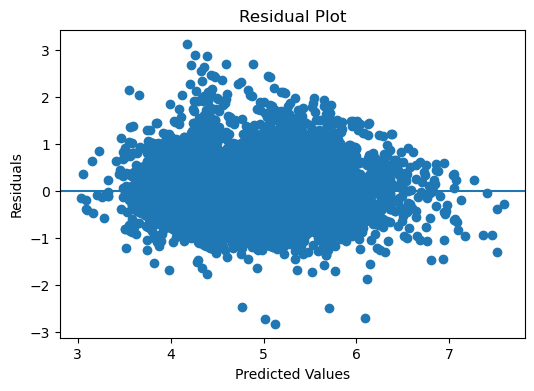

In [43]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The residual plot shows how the prediction errors are distributed around zero. Since the residuals appear to be relatively scattered without a strong pattern, the assumption of linearity and constant variance appears reasonably satisfied.

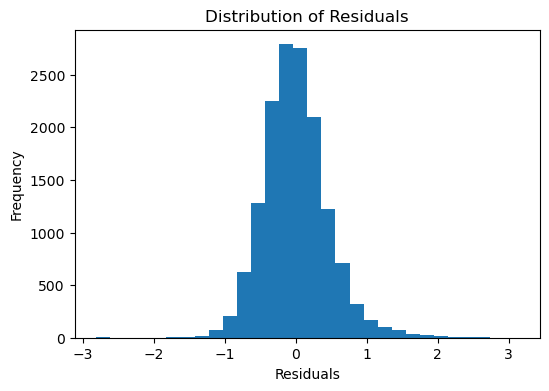

In [44]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

The histogram of residuals appears to be bell shaped which can indicate that the residuals are reasonably close to a normal distribution. This means that the normality assumption for linear regression can be considered generally satisfied.

## Results and Conclusion 

This project analyzed Airbnb listing data to predict market listing prices using multiple linear regression. After cleaning and preparing the dataset, the model was able to explain about 58% of the variation in Airbnb prices, showing that factors such as location, property type, and listing characteristics play a major role in pricing. The results suggest that regression modeling can be useful for predicting prices and identifying patterns within real world housing data. Although the model produced reasonably accurate predictions, some variation in pricing still could not be explained because outside factors, such as demand, seasonality, reviews, and market trends, may also influence listing prices. Overall, this project demonstrated how data analysis and regression modeling can be used to better understand pricing behavior and make predictions using real world datasets.